In [79]:
# https://vme.ices.dk/download.aspx
# dataset on vulnerable marine ecologies 
# species reported are associated with vulnerable marine ecologies (vme)

import random
import pandas as pd
from pandas.api.types import CategoricalDtype
import seaborn as sns
import matplotlib.pyplot as plt 
import plotly.express as px 


In [80]:
df_vme_ecosystem = pd.read_csv('data/VMEDataSet2025513.csv')

df_vme_ecosystem.head()


/var/folders/4b/sly201491lz119kc400w1qrm0000gn/T/ipykernel_26768/252022274.py:1: DtypeWarning:

Columns (1,2,5,6,7,8,9,10,11,16,17,18,19,20,21,22,23,24,25,26,31,35,36,37,38,46,47) have mixed types. Specify dtype option on import or set low_memory=False.



,ICES_ID,CruiseID,Sample,RecodKey,VME_Indicator,HabitatType,status,VME_Habitat_Subtype,VMEKey,HighestTaxonomicResolution,...,FileName,PointOfContact,ResponsibleOrganisation,ResponsibleOrganizationRole,ContactEmail,DataAccess,DepthUpper,DepthLower,Comments1,Comments2
0,261417,NaN,NaN,1,NaN,Cold seeps,Present,NaN,NaN,Habitat,...,CHESS99_WGDEC_2013_001,Maria Baker,NaN,NaN,mb11@noc.soton.ac.uk,Public,NaN,NaN,NaN,NaN
1,261703,NaN,NaN,2,NaN,Cold seeps,Present,NaN,NaN,Habitat,...,CHESS99_WGDEC_2013_001,Maria Baker,NaN,NaN,mb11@noc.soton.ac.uk,Public,NaN,350.0,Megafauna at the seabed is sparse_ consisting ...,NaN
2,261418,NaN,NaN,3,NaN,Cold seeps,Present,NaN,NaN,Habitat,...,CHESS99_WGDEC_2013_001,Maria Baker,NaN,NaN,mb11@noc.soton.ac.uk,Public,NaN,1100.0,mass of mytilids identified as Bathymodiolus m...,NaN
3,261080,NaN,NaN,4,NaN,Cold seeps,Present,NaN,NaN,Habitat,...,CHESS99_WGDEC_2013_001,Maria Baker,NaN,NaN,mb11@noc.soton.ac.uk,Public,NaN,NaN,NaN,NaN
4,261081,NaN,NaN,5,NaN,Cold seeps,Present,NaN,NaN,Habitat,...,CHESS99_WGDEC_2013_001,Maria Baker,NaN,NaN,mb11@noc.soton.ac.uk,Public,NaN,2200.0,Carlos Ribeiro displays a rich array of megafa...,NaN


In [81]:
df_vme_ecosystem.describe()

,ICES_ID,Density,Number,Weight_kg,PercentageCover,StartLatitude,EndLatitude,StartLongitude,EndLongitude,MiddleLatitude,MiddleLongitude,RecordPositionAccuracy,ResponsibleOrganisation,DepthUpper,DepthLower
count,70819.000000,0.0,39813.000000,57279.000000,0.0,62179.000000,31588.000000,62179.000000,31588.000000,62179.000000,62179.000000,34552.000000,60618.000000,33872.000000,32295.000000
mean,305883.506502,NaN,25.102907,4.735838,NaN,52.639088,52.991632,-32.908976,-27.493427,52.526818,-32.803435,425.032646,1742.515870,437.465305,456.411561
std,29209.163056,NaN,1297.215516,78.086237,NaN,10.242358,12.843064,30.586744,29.462746,10.463960,30.596184,1318.337824,787.514305,300.139544,323.332118
min,258506.000000,NaN,0.000000,0.000000,NaN,35.250000,0.000000,-79.734020,-79.680650,0.000000,-79.707317,0.000000,17.000000,-1053.000000,0.000000
25%,283345.500000,NaN,1.000000,0.000000,NaN,44.377600,47.233375,-57.570500,-58.313750,44.376526,-57.570408,30.000000,1351.000000,254.000000,256.000000
50%,303362.000000,NaN,1.000000,0.000000,NaN,48.119619,51.582000,-55.415000,-14.410000,48.115340,-55.173333,30.000000,1811.000000,360.000000,374.000000
75%,321676.500000,NaN,2.000000,0.000000,NaN,59.061700,59.106175,-7.647294,-6.606500,58.800200,-7.530204,30.000000,1979.000000,560.000000,579.000000
max,367106.000000,NaN,202404.000000,8810.000000,NaN,86.983300,86.983300,55.500000,55.500000,86.983300,55.500000,10717.000000,4766.000000,3900.000000,4300.000000


In [82]:
# checking for duplicate Rows
print(df_vme_ecosystem[df_vme_ecosystem.duplicated()])

Empty DataFrame
Columns: [ICES_ID, CruiseID, Sample, RecodKey, VME_Indicator, HabitatType, status, VME_Habitat_Subtype, VMEKey, HighestTaxonomicResolution, Species, Dead_Alive, Density, Number, Weight_kg, PercentageCover, SACFOR, TaxonDeterminer, TaxonDeterminationDate, ObsDate, ObsDateType, StationID, SurveyKey, Ship, SurveyMethod, VesselType, PlaceName, StartLatitude, EndLatitude, StartLongitude, EndLongitude, GeometryType, MiddleLatitude, MiddleLongitude, RecordPositionAccuracy, ShipPositionPrecision, Reference, DataOwner, FileName, PointOfContact, ResponsibleOrganisation, ResponsibleOrganizationRole, ContactEmail, DataAccess, DepthUpper, DepthLower, Comments1, Comments2]
Index: []

[0 rows x 48 columns]


In [83]:
# checking and handling missing values 
for column in df_vme_ecosystem.columns:
    print(f"Null Values in column '{column}' are: ", df_vme_ecosystem[column].isnull().sum())
    

Null Values in column 'ICES_ID' are:  0
Null Values in column 'CruiseID' are:  17353
Null Values in column 'Sample' are:  11258
Null Values in column 'RecodKey' are:  26
Null Values in column 'VME_Indicator' are:  6242
Null Values in column 'HabitatType' are:  60917
Null Values in column 'status' are:  62106
Null Values in column 'VME_Habitat_Subtype' are:  67031
Null Values in column 'VMEKey' are:  59861
Null Values in column 'HighestTaxonomicResolution' are:  63641
Null Values in column 'Species' are:  47308
Null Values in column 'Dead_Alive' are:  20496
Null Values in column 'Density' are:  70819
Null Values in column 'Number' are:  31006
Null Values in column 'Weight_kg' are:  13540
Null Values in column 'PercentageCover' are:  70819
Null Values in column 'SACFOR' are:  68144
Null Values in column 'TaxonDeterminer' are:  36273
Null Values in column 'TaxonDeterminationDate' are:  64502
Null Values in column 'ObsDate' are:  8640
Null Values in column 'ObsDateType' are:  9448
Null Val

In [84]:
# choosing columns for analysis

columns_analysis = ['Species', 'HabitatType', 'status', 'StartLatitude', 'StartLongitude', 'DepthLower', 'Weight_kg', 'Number']

df_vme_clean = df_vme_ecosystem[columns_analysis].copy()

# dropping rows with missing values 
df_vme_clean = df_vme_clean.dropna(subset=['Species','StartLatitude', 'StartLongitude'])

#remove rows with lacking ecological data values 
columns = ['Weight_kg', 'Number', 'DepthLower', ]
df_vme_clean = df_vme_clean[~(df_vme_clean[columns] == 0).all(axis=1)]  

# filling missing values with median due to skewed data  
df_vme_clean['DepthLower'] = df_vme_clean.groupby('Species')['DepthLower'].transform(lambda x: x.fillna(x.median())) 
df_vme_clean['DepthLower'] = df_vme_clean['DepthLower'].fillna(df_vme_clean['DepthLower'].median())

df_vme_clean['Weight_kg'] = df_vme_clean.groupby('Species')['Weight_kg'].transform(lambda x: x.fillna(x.median()))
df_vme_clean['Weight_kg'] = df_vme_clean['Weight_kg'].fillna(df_vme_clean['Weight_kg'].median())

# fill missing values 'HabitatType' with 'Unknown'
df_vme_clean['HabitatType'] = df_vme_clean['HabitatType'].fillna('Unknown')

df_vme_clean.sample(5)
    

,Species,HabitatType,status,StartLatitude,StartLongitude,DepthLower,Weight_kg,Number
7343,Gorgonacea,Unknown,Present,63.348400,7.140950,117.01,0.0,1.0
7292,Gorgonacea,Unknown,Present,67.426700,9.421030,281.55,0.0,1.0
53113,Virgularia mirabilis,Unknown,NaN,51.894200,-13.739200,148.00,0.0,NaN
53456,Polymastia hemisphaerica,Unknown,NaN,74.045193,23.980478,368.08,0.0,1.0
46085,Polymastiidae,Unknown,NaN,74.031667,25.560000,435.00,0.0,3.0


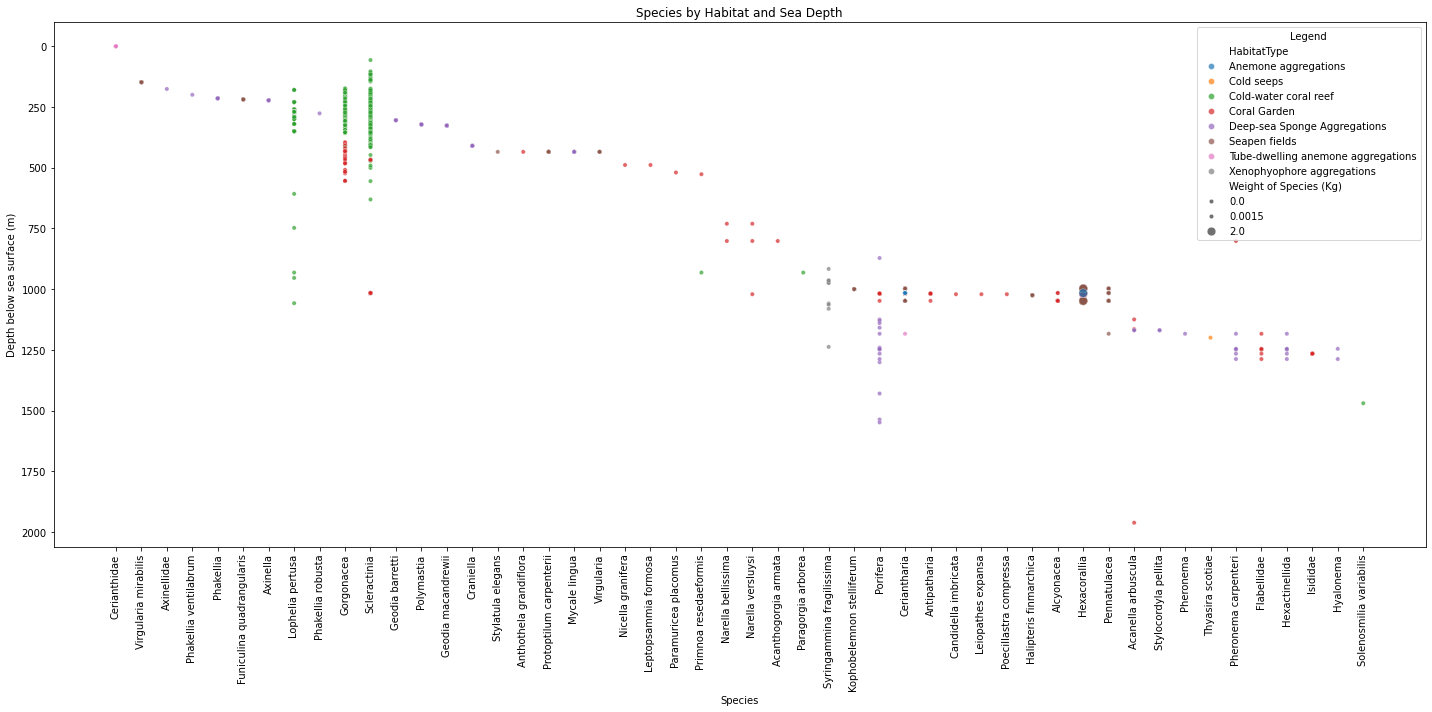

In [85]:
# visualization 1: scatter with all species

# excluding "Unknown' 
df_species = df_vme_clean[df_vme_clean['HabitatType'] != 'Unknown'].copy()

species_order = df_species.groupby('Species')['DepthLower'].median().sort_values().index
df_species['Species'] = df_species['Species'].astype(CategoricalDtype(categories=species_order, ordered=True))

# plotting 
plt.figure(figsize=(20, 10))
scatter = sns.scatterplot(data=df_species, x='Species', y='DepthLower', hue='HabitatType', size='Weight_kg', alpha=0.7, 
               hue_order=sorted(df_species['HabitatType'].dropna().unique()) )               
plt.gca().invert_yaxis()
plt.xticks(rotation=90)
plt.title('Species by Habitat and Sea Depth')
plt.xlabel('Species')
plt.ylabel('Depth below sea surface (m)')

# legend
scatter.legend_.set_title("Legend") 
for text in scatter.legend_.get_texts():
    if text.get_text() == "Weight_kg":text.set_text("Weight of Species (Kg) ")
                
plt.xticks(rotation=90)
plt.tight_layout()
plt.show()

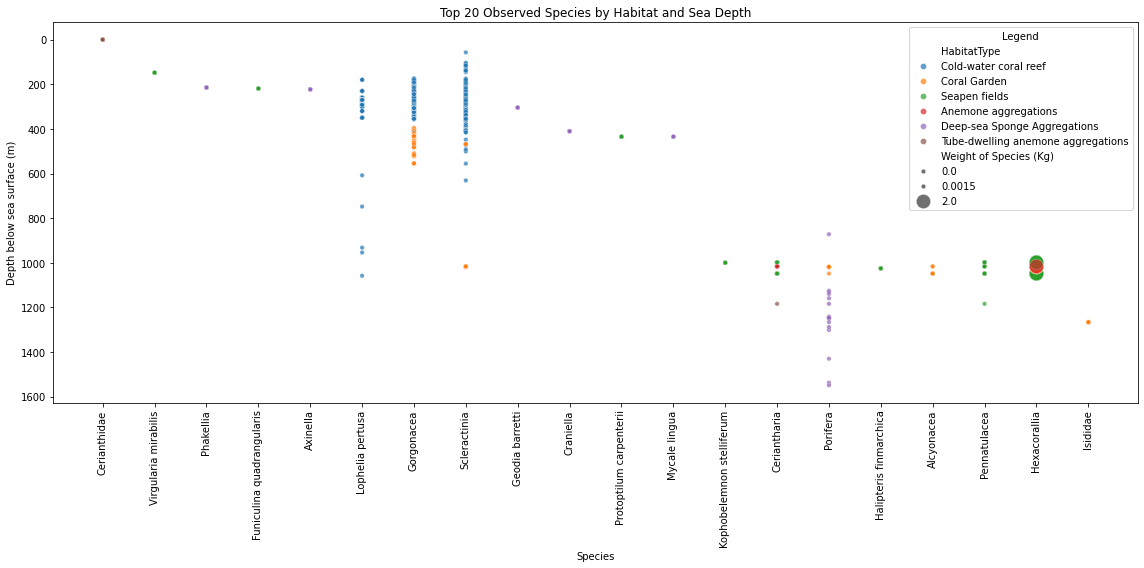

In [92]:
# visualization 2: scatter with top20 species

# excluding "Unknown' 
df_species = df_vme_clean[df_vme_clean['HabitatType'] != 'Unknown'].copy()

# focusing on top 20 most frequently observed species
top_species = df_species['Species'].value_counts().nlargest(20).index
df_species = df_species[df_species['Species'].isin(top_species)].copy()

species_order = df_species.groupby('Species')['DepthLower'].median().sort_values().index
df_species['Species'] = df_species['Species'].astype(CategoricalDtype(categories=species_order, ordered=True))

# plotting 
plt.figure(figsize=(16, 8))
scatter= sns.scatterplot(data=df_species, x='Species', y='DepthLower', hue='HabitatType', size='Weight_kg', alpha=0.7, legend='full', 
               sizes=(20, 200))               
plt.gca().invert_yaxis()
plt.xticks(rotation=90)
plt.title('Top 20 Observed Species by Habitat and Sea Depth')
plt.xlabel('Species')
plt.ylabel('Depth below sea surface (m)')

# legend
scatter.legend_.set_title("Legend") 
for text in scatter.legend_.get_texts():
    if text.get_text() == "Weight_kg":text.set_text("Weight of Species (Kg) ")
                
plt.xticks(rotation=90)
plt.tight_layout()
plt.savefig('top_20_species.png', dpi=300, bbox_inches='tight')
plt.show()

In [90]:
#import os
#os.makedirs("docs/data/visual_charts_graphs", exist_ok=True)

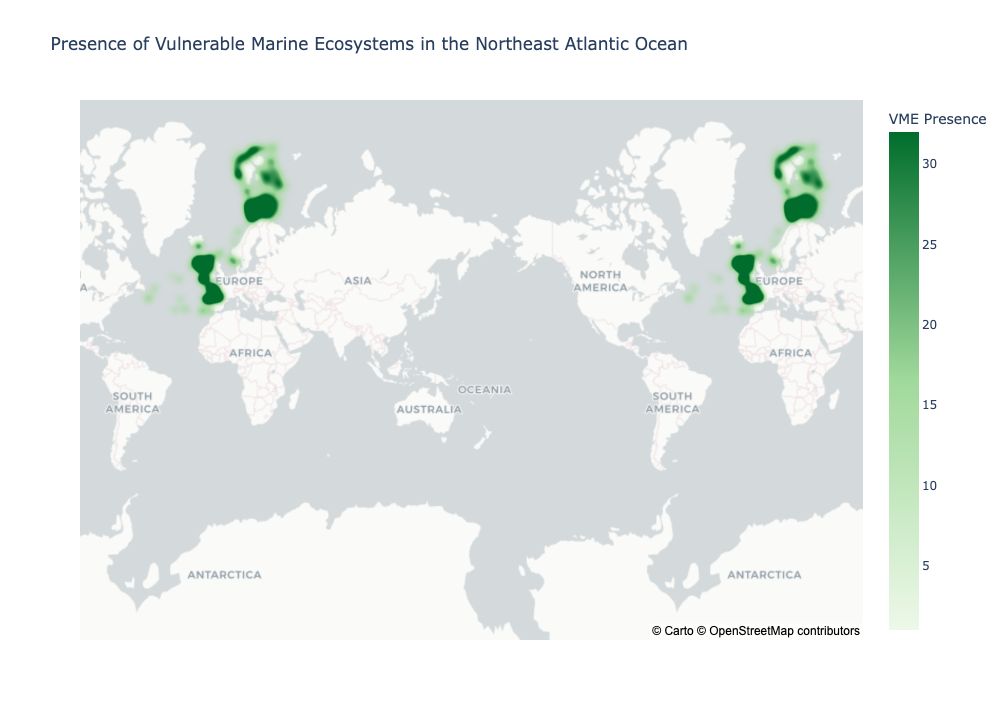

In [91]:
# visualization 3: Biodiversity Richness by lat and lon

# exclude data with missing coordinates
df_species_vme = df_vme_clean.dropna(subset=['Species', 'StartLatitude', 'StartLongitude']).copy()

# bin coordinates to create regions
df_species_vme['lat_bin'] = df_species_vme['StartLatitude'].round(1)
df_species_vme['lon_bin'] = df_species_vme['StartLongitude'].round(1)

# species per region (vme presence)
presence_vme = (df_species_vme.groupby(['lat_bin', 'lon_bin'])['Species'].nunique().reset_index(name='VME Presence'))

presence_vme = presence_vme.rename(columns={'lat_bin': 'Latitude Bin','lon_bin': 'Longitude Bin'})
# plotting 
fig = px.density_mapbox(
    presence_vme,
    lat='Latitude Bin',
    lon='Longitude Bin',
    z='VME Presence',
    radius=10,
    center=dict(lat=df_species_vme['StartLatitude'].mean(), lon=df_species_vme['StartLongitude'].mean()),
    zoom=2.5,
    mapbox_style="carto-positron",
    color_continuous_scale=[
    "#edf8e9",  
    "#a1d99b", 
    "#006d2c"],
    title="Presence of Vulnerable Marine Ecosystems in the Northeast Atlantic Ocean")

fig.show()

fig.write_html("docs/data/visual_charts_graphs/vme_presence_heatmap.html")
